# Gradient Descent — From Scratch

**Goal:** Predict an employee's **salary** from their **years of experience** using Gradient Descent.

---

### What is Gradient Descent?

It's how a model **learns**. We start with bad guesses for slope (`m`) and intercept (`b`), then slowly adjust them to reduce the error.

**Update rule:**
```
m = m - learning_rate × (derivative of error w.r.t m)
b = b - learning_rate × (derivative of error w.r.t b)
```

**Analogy:** You're blindfolded on a hill and want to reach the valley.
- You feel the slope under your feet → that's the **gradient**
- You take a step downhill → that's the **update**
- The step size is your **learning rate**

---

### Two different plots — don't confuse them!

| Plot | What's on it | Shape | What it means |
|------|-------------|-------|---------------|
| **Data plot** | Experience vs Salary | Straight line | The pattern we want to learn |
| **Loss surface** | Slope vs Intercept vs Error | Curved bowl | Where gradient descent actually walks |

The data is a straight line. But gradient descent walks on the **loss surface** — a bowl-shaped curve that shows the error for every possible (m, b) pair. We'll see this bowl later.

---
## Step 1: Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression

---
## Step 2: Load the Data

Real-world dataset: **30 employees** with just two columns — years of experience and salary.

In [2]:
url = "https://raw.githubusercontent.com/krishnaik06/simple-Linear-Regression/master/Salary_Data.csv"
df = pd.read_csv(url)

df.head(10)

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0
5,2.9,56642.0
6,3.0,60150.0
7,3.2,54445.0
8,3.2,64445.0
9,3.7,57189.0


---
## Step 3: Explore the Data

In [3]:
# Shape: how many rows and columns?
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print(f"Column names: {list(df.columns)}")

Rows: 30, Columns: 2
Column names: ['YearsExperience', 'Salary']


In [4]:
# Data types and memory
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes


In [5]:
# Basic statistics: min, max, mean, std, quartiles
df.describe()

,YearsExperience,Salary
count,30.000000,30.000000
mean,5.313333,76003.000000
std,2.837888,27414.429785
min,1.100000,37731.000000
25%,3.200000,56720.750000
50%,4.700000,65237.000000
75%,7.700000,100544.750000
max,10.500000,122391.000000


In [6]:
# Missing values?
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
YearsExperience    0
Salary             0
dtype: int64


In [7]:
# Duplicate rows?
print(f"Duplicate rows: {df.duplicated().sum()}")

Duplicate rows: 0


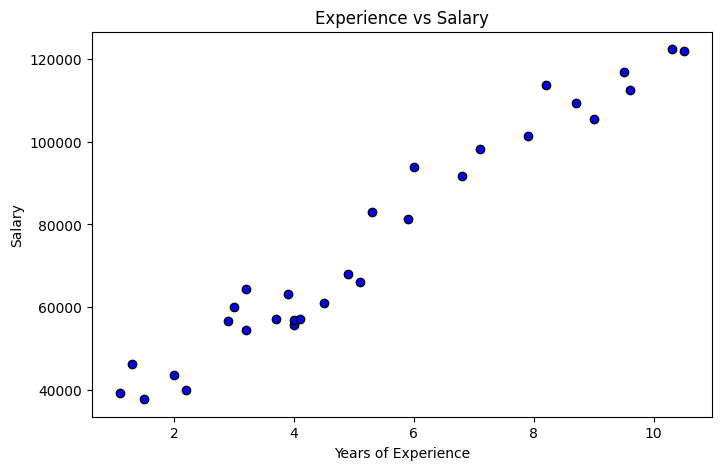

In [8]:
# Visualize the data
plt.figure(figsize=(8, 5))
plt.scatter(df['YearsExperience'], df['Salary'], color='blue', edgecolors='black')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.title('Experience vs Salary')
plt.show()

# Clear linear pattern — good fit for gradient descent

---
## Step 4: Data Preparation

### 4a. Check for Outliers

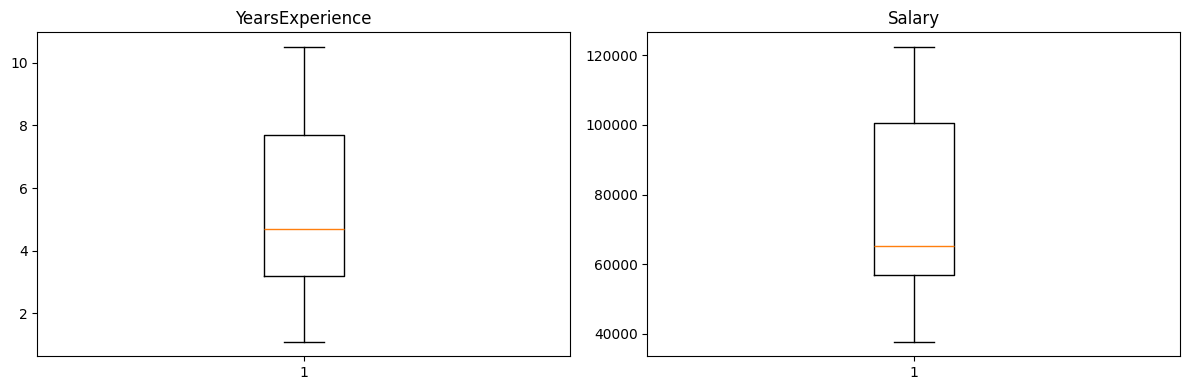

In [9]:
# Boxplots — quick visual check for outliers
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].boxplot(df['YearsExperience'])
axes[0].set_title('YearsExperience')
axes[1].boxplot(df['Salary'])
axes[1].set_title('Salary')
plt.tight_layout()
plt.show()

In [10]:
# IQR method: outlier = anything below Q1-1.5*IQR or above Q3+1.5*IQR
for col in ['YearsExperience', 'Salary']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outliers)} outliers  (valid range: {lower:.1f} to {upper:.1f})")

# No outliers — data is clean

YearsExperience: 0 outliers  (valid range: -3.5 to 14.4)
Salary: 0 outliers  (valid range: -9015.2 to 166280.8)


### 4b. Extract Features and Target

In [11]:
X = df['YearsExperience'].values  # feature
y = df['Salary'].values            # target

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (30,)
y shape: (30,)


### 4c. Train-Test Split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples:  {len(X_test)}")

Training samples: 24
Testing samples:  6


### 4d. Feature Scaling

**Why?** Right now X is 1–10 and y is 37,000–122,000. Very different scales.

Gradient descent uses derivatives — if numbers are huge, the gradients are huge, and the model overshoots wildly. Scaling both to mean≈0, std≈1 makes gradient descent converge smoothly.

In [13]:
# Save mean and std so we can undo the scaling later
X_mean, X_std = X_train.mean(), X_train.std()
y_mean, y_std = y_train.mean(), y_train.std()

# Scale: (value - mean) / std
X_train_s = (X_train - X_mean) / X_std
X_test_s = (X_test - X_mean) / X_std
y_train_s = (y_train - y_mean) / y_std
y_test_s = (y_test - y_mean) / y_std

print("Before scaling:")
print(f"  X_train → mean={X_train.mean():.1f}, std={X_train.std():.1f}")
print(f"  y_train → mean={y_train.mean():.0f}, std={y_train.std():.0f}")
print()
print("After scaling:")
print(f"  X_train_s → mean={X_train_s.mean():.4f}, std={X_train_s.std():.4f}")
print(f"  y_train_s → mean={y_train_s.mean():.4f}, std={y_train_s.std():.4f}")

Before scaling:
  X_train → mean=5.2, std=2.9
  y_train → mean=74208, std=27646

After scaling:
  X_train_s → mean=0.0000, std=1.0000
  y_train_s → mean=0.0000, std=1.0000


---
## Step 5: Gradient Descent — From Scratch

We want to fit the line: **y = m × x + b**

- `m` = slope (how much salary goes up per year)
- `b` = intercept (salary at 0 years experience)

**Loss function** (what we minimize): Mean Squared Error

```
MSE = (1/n) × Σ(y_actual - y_predicted)²
```

**Gradients** (partial derivatives — which direction to nudge m and b):

```
dm = (-2/n) × Σ(x × (y - ŷ))     ← how much to change slope
db = (-2/n) × Σ(y - ŷ)            ← how much to change intercept
```

In [14]:
class GradientDescentRegressor:

    def __init__(self, learning_rate=0.01, epochs=100):
        self.lr = learning_rate       # step size
        self.epochs = epochs           # number of full passes
        self.m = 0                     # slope — start at 0
        self.b = 0                     # intercept — start at 0
        self.loss_history = []         # track error over time

    def fit(self, X, y):
        n = len(X)

        for epoch in range(self.epochs):
            # 1. Predict with current m and b
            y_pred = self.m * X + self.b

            # 2. Calculate error
            mse = np.mean((y - y_pred) ** 2)
            self.loss_history.append(mse)

            # 3. Compute gradients
            dm = (-2 / n) * np.sum(X * (y - y_pred))
            db = (-2 / n) * np.sum(y - y_pred)

            # 4. Update m and b
            self.m = self.m - self.lr * dm
            self.b = self.b - self.lr * db

    def predict(self, X):
        return self.m * X + self.b

---
## Step 6: Train the Model

In [15]:
model = GradientDescentRegressor(learning_rate=0.01, epochs=200)
model.fit(X_train_s, y_train_s)

print(f"Slope (scaled):     {model.m:.4f}")
print(f"Intercept (scaled): {model.b:.4f}")
print(f"Final MSE (scaled): {model.loss_history[-1]:.4f}")

Slope (scaled):     0.9648
Intercept (scaled): -0.0000
Final MSE (scaled): 0.0358


In [16]:
# Predict on test set (scaled)
y_pred_s = model.predict(X_test_s)

# Convert back to original scale: value × std + mean
y_pred = y_pred_s * y_std + y_mean

# Convert slope and intercept back to original scale
m_original = model.m * (y_std / X_std)
b_original = y_mean - m_original * X_mean

print(f"Slope (original):     {m_original:.2f}  ← salary increase per year")
print(f"Intercept (original): {b_original:.2f}  ← estimated base salary")

Slope (original):     9258.07  ← salary increase per year
Intercept (original): 26181.39  ← estimated base salary


---
## Step 7: Evaluate

In [17]:
r2   = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)

print("Our Gradient Descent Model:")
print(f"  R² Score : {r2:.4f}   (1.0 = perfect, 0 = useless)")
print(f"  RMSE     : {rmse:.2f}  (avg error in salary units)")
print(f"  MAE      : {mae:.2f}  (avg absolute error)")

Our Gradient Descent Model:
  R² Score : 0.9012   (1.0 = perfect, 0 = useless)
  RMSE     : 7103.10  (avg error in salary units)
  MAE      : 6245.02  (avg absolute error)


---
## Step 8: Visualizations

### 8a. Regression Line on Data

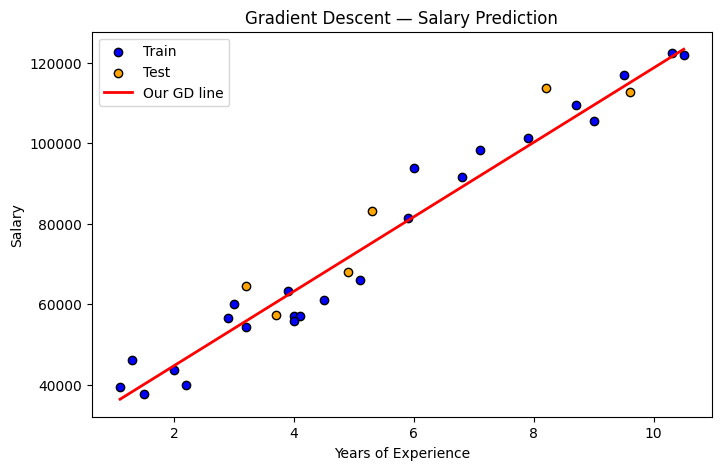

In [18]:
plt.figure(figsize=(8, 5))
plt.scatter(X_train, y_train, color='blue', label='Train', edgecolors='black')
plt.scatter(X_test, y_test, color='orange', label='Test', edgecolors='black')

# Draw our regression line
line_x = np.linspace(X.min(), X.max(), 100)
line_y = m_original * line_x + b_original
plt.plot(line_x, line_y, color='red', linewidth=2, label='Our GD line')

plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.title('Gradient Descent — Salary Prediction')
plt.legend()
plt.show()

### 8b. Actual vs Predicted

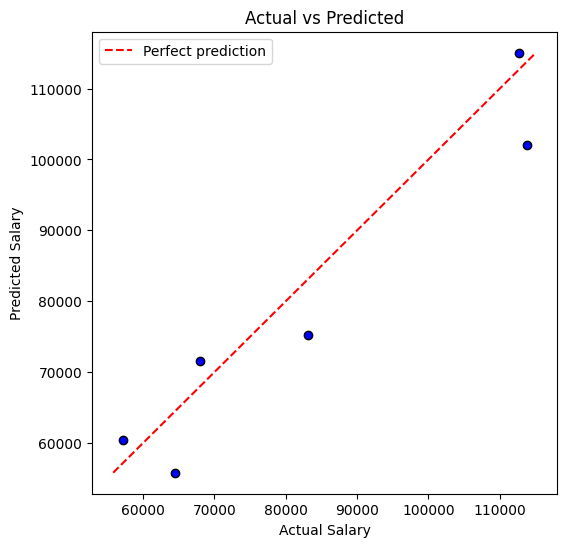

In [19]:
# Points close to the diagonal = good predictions
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, color='blue', edgecolors='black')

# Perfect prediction line
lo = min(y_test.min(), y_pred.min())
hi = max(y_test.max(), y_pred.max())
plt.plot([lo, hi], [lo, hi], 'r--', label='Perfect prediction')

plt.xlabel('Actual Salary')
plt.ylabel('Predicted Salary')
plt.title('Actual vs Predicted')
plt.legend()
plt.show()

### 8c. Loss Curve (How the model learned)

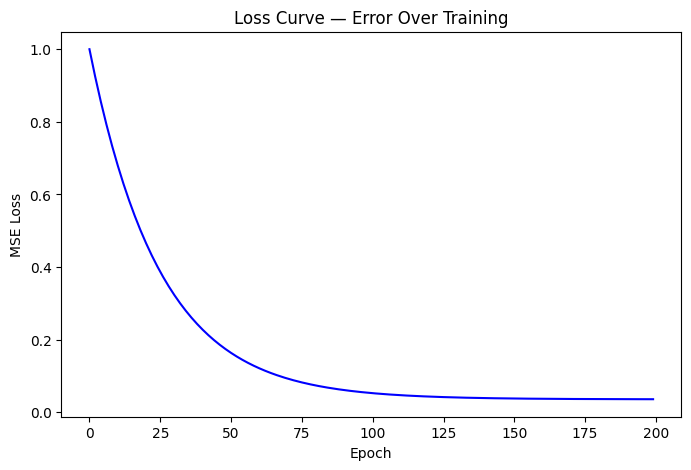

Starting error: 1.0000
Final error:    0.0358


In [20]:
# Loss should go DOWN — model is getting better each epoch
plt.figure(figsize=(8, 5))
plt.plot(model.loss_history, color='blue')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Loss Curve — Error Over Training')
plt.show()

print(f"Starting error: {model.loss_history[0]:.4f}")
print(f"Final error:    {model.loss_history[-1]:.4f}")

### 8d. Residuals (Prediction Errors)

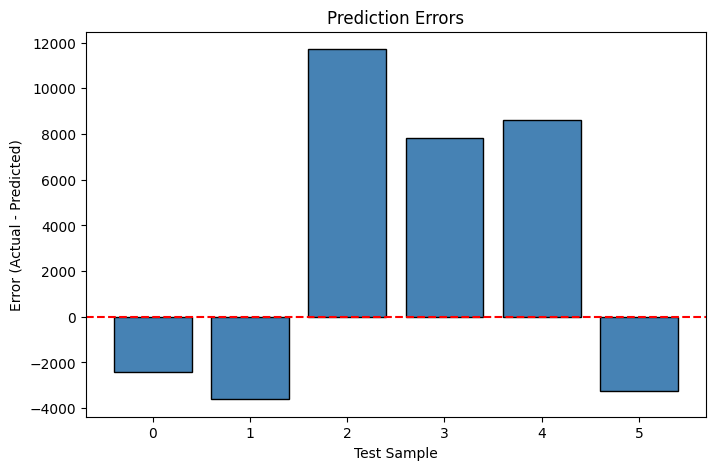

Average error: 3152.01  (close to 0 = good)


In [21]:
# Residual = actual - predicted
# A good model has residuals scattered around 0
residuals = y_test - y_pred

plt.figure(figsize=(8, 5))
plt.bar(range(len(residuals)), residuals, color='steelblue', edgecolor='black')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Test Sample')
plt.ylabel('Error (Actual - Predicted)')
plt.title('Prediction Errors')
plt.show()

print(f"Average error: {residuals.mean():.2f}  (close to 0 = good)")

### 8e. The Loss Surface — The "Bowl"

This is the curved surface where gradient descent actually walks.

We compute the MSE for **every possible (m, b) combination** and plot it.
The result is a bowl — gradient descent starts on the rim and rolls to the bottom.

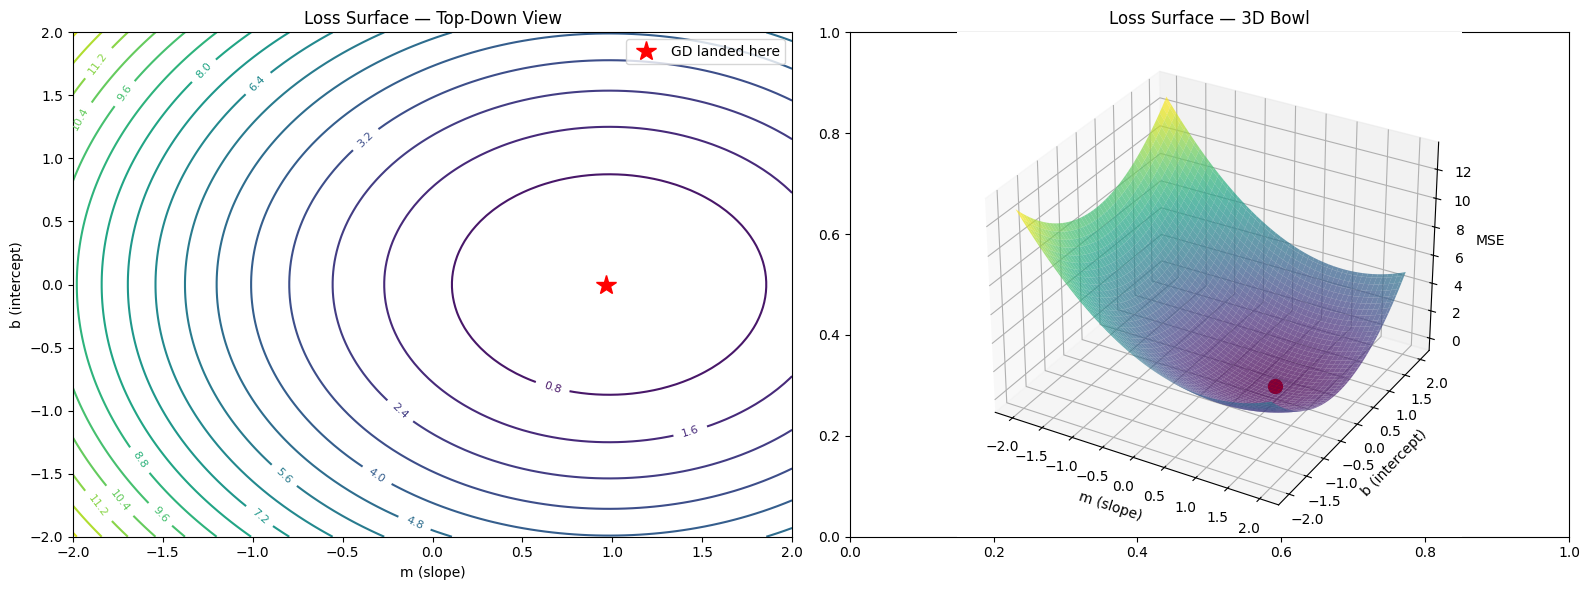

The data is a straight line, but the LOSS SURFACE is a bowl.
Gradient descent walks on this bowl, not on the data.


In [22]:
# Try a grid of m and b values, compute MSE for each
m_vals = np.linspace(-2, 2, 100)
b_vals = np.linspace(-2, 2, 100)
M_grid, B_grid = np.meshgrid(m_vals, b_vals)

Z = np.zeros_like(M_grid)
for i in range(M_grid.shape[0]):
    for j in range(M_grid.shape[1]):
        y_hat = M_grid[i, j] * X_train_s + B_grid[i, j]
        Z[i, j] = np.mean((y_train_s - y_hat) ** 2)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: contour (top-down view, like a topographic map)
contour = axes[0].contour(M_grid, B_grid, Z, levels=20, cmap='viridis')
axes[0].clabel(contour, inline=True, fontsize=8)
axes[0].plot(model.m, model.b, 'r*', markersize=15, label='GD landed here')
axes[0].set_xlabel('m (slope)')
axes[0].set_ylabel('b (intercept)')
axes[0].set_title('Loss Surface — Top-Down View')
axes[0].legend()

# Right: 3D surface (the actual bowl)
ax3d = fig.add_subplot(122, projection='3d')
ax3d.plot_surface(M_grid, B_grid, Z, cmap='viridis', alpha=0.7)
ax3d.scatter(model.m, model.b, model.loss_history[-1],
             color='red', s=100, label='GD landed here')
ax3d.set_xlabel('m (slope)')
ax3d.set_ylabel('b (intercept)')
ax3d.set_zlabel('MSE')
ax3d.set_title('Loss Surface — 3D Bowl')

plt.tight_layout()
plt.show()

print("The data is a straight line, but the LOSS SURFACE is a bowl.")
print("Gradient descent walks on this bowl, not on the data.")

---
## Step 9: Compare with Sklearn

Sklearn uses a direct math formula (OLS) — no iteration needed. Let's see if our gradient descent matches it.

In [23]:
# Sklearn expects X as 2D array: (n_samples, 1)
sk_model = LinearRegression()
sk_model.fit(X_train.reshape(-1, 1), y_train)

y_pred_sk = sk_model.predict(X_test.reshape(-1, 1))

r2_sk   = r2_score(y_test, y_pred_sk)
rmse_sk = np.sqrt(mean_squared_error(y_test, y_pred_sk))
mae_sk  = mean_absolute_error(y_test, y_pred_sk)

In [24]:
# Side-by-side comparison
print("=" * 55)
print(f"{'Metric':<15} {'Our GD':<20} {'Sklearn OLS':<20}")
print("=" * 55)
print(f"{'Slope':<15} {m_original:<20.2f} {sk_model.coef_[0]:<20.2f}")
print(f"{'Intercept':<15} {b_original:<20.2f} {sk_model.intercept_:<20.2f}")
print(f"{'R²':<15} {r2:<20.4f} {r2_sk:<20.4f}")
print(f"{'RMSE':<15} {rmse:<20.2f} {rmse_sk:<20.2f}")
print(f"{'MAE':<15} {mae:<20.2f} {mae_sk:<20.2f}")
print("=" * 55)

Metric          Our GD               Sklearn OLS         
Slope           9258.07              9423.82             
Intercept       26181.39             25321.58            
R²              0.9012               0.9024              
RMSE            7103.10              7059.04             
MAE             6245.02              6286.45             


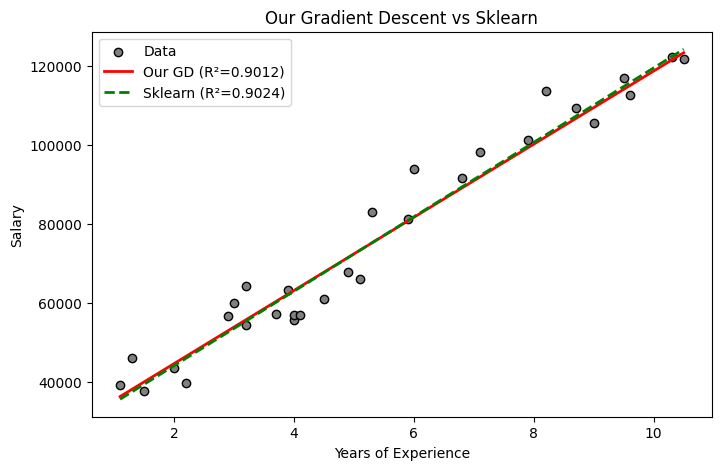

In [25]:
# Both lines on the same plot — they should nearly overlap
plt.figure(figsize=(8, 5))
plt.scatter(X, y, color='gray', edgecolors='black', label='Data')

line_x = np.linspace(X.min(), X.max(), 100)
plt.plot(line_x, m_original * line_x + b_original,
         color='red', linewidth=2, label=f'Our GD (R²={r2:.4f})')
plt.plot(line_x, sk_model.coef_[0] * line_x + sk_model.intercept_,
         color='green', linewidth=2, linestyle='--', label=f'Sklearn (R²={r2_sk:.4f})')

plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.title('Our Gradient Descent vs Sklearn')
plt.legend()
plt.show()

---
## Step 10: Effect of Learning Rate

The most important hyperparameter. Let's see what happens when we change it.

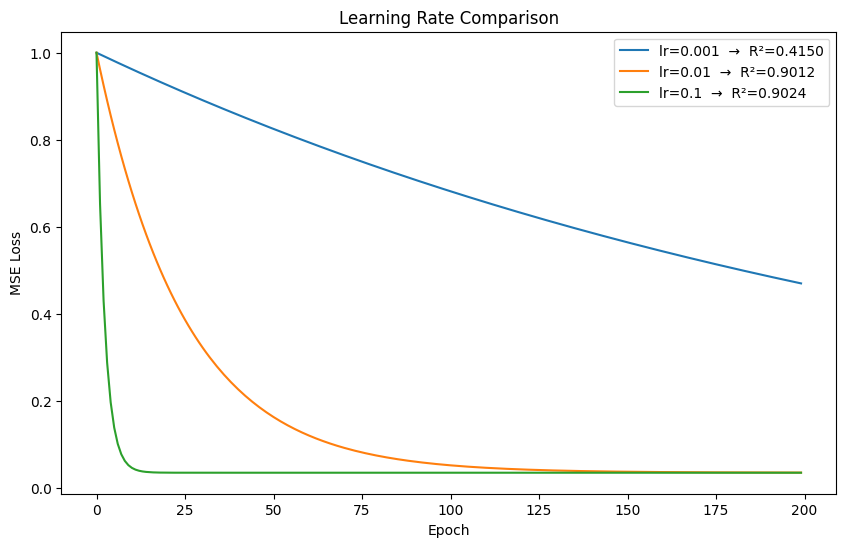

lr=0.001 → learns slowly (loss drops slowly)
lr=0.01  → good balance
lr=0.1   → learns fast (might overshoot)


In [26]:
learning_rates = [0.001, 0.01, 0.1]

plt.figure(figsize=(10, 6))

for lr in learning_rates:
    gd = GradientDescentRegressor(learning_rate=lr, epochs=200)
    gd.fit(X_train_s, y_train_s)

    y_p = gd.predict(X_test_s) * y_std + y_mean
    r2_val = r2_score(y_test, y_p)

    plt.plot(gd.loss_history, label=f'lr={lr}  →  R²={r2_val:.4f}')

plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Learning Rate Comparison')
plt.legend()
plt.show()

print("lr=0.001 → learns slowly (loss drops slowly)")
print("lr=0.01  → good balance")
print("lr=0.1   → learns fast (might overshoot)")

---
## Summary

| What | Result |
|------|--------|
| **Dataset** | 30 employees — experience vs salary |
| **Missing values** | None |
| **Outliers** | None |
| **Algorithm** | Gradient Descent from scratch |
| **Hyperparameters** | lr=0.01, epochs=200 |
| **Our R²** | ~0.90 |
| **Sklearn R²** | ~0.90 (matches!) |
| **Slope meaning** | ~9,400 salary increase per year |

### Key Takeaways

1. **Gradient descent finds the same answer** as the direct formula — just takes more steps
2. **Learning rate** is critical — too high = chaos, too low = slow
3. **Feature scaling** is essential — without it, gradients explode
4. **Loss curve** should always go down — if it goes up, learning rate is too high
5. The **data** is a straight line, but the **loss surface** is a bowl — that's where GD walks